In [1]:
import torch
from torch import nn
import ptwt
import numpy as np
from torch_geometric.nn.conv import GATConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.nn import Sequential
from torch_geometric.data import Data, Batch
from dataset import WaveletDataset
from torch_geometric.loader import DataLoader
import torch.utils.data as torchdata
import tqdm
from math import floor
import gc
from torchaudio.transforms import PSD
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [7]:
N = 5 # your choice goes here
vals = torch.arange(N*(N+1)/2) + 1 # values

A = torch.zeros(N, N)
i, j = torch.triu_indices(N, N)
A[i, j] = vals
A.T[i, j] = vals

B = torch.zeros(N, N)
i, j = torch.triu_indices(N, N)
B[i, j] = -vals
B.T[i, j] = -vals

In [11]:
def MatrixCosineSimilarity(A, B):
    _, a_eigenvec = torch.linalg.eigh(A, UPLO='L')
    _, b_eigenvec = torch.linalg.eigh(B, UPLO='L')

    sim = 0
    assert a_eigenvec.shape == b_eigenvec.shape
    for i in range(a_eigenvec.shape[1]):
        sim += torch.dot(a_eigenvec[:, i], b_eigenvec[:, i])

    return sim

def BatchWiseMatrixSimilarity(batch_A, batch_B):
    assert batch_A.shape == batch_B.shape
    B, N, N = batch_A.shape
    ''' This could be accelerated '''
    output = torch.zeros(B, B)

    for i in range(B):
        for j in range(B):
            output[i, j] = MatrixCosineSimilarity(batch_A[i], batch_B[i])
    return output




print(A)
print(B)
sim = MatrixCosineSimilarity(A, B)
print(sim)
output = BatchWiseMatrixSimilarity(A[None, :], B[None, :]) 
print(output.shape)

tensor([[ 1.,  2.,  3.,  4.,  5.],
        [ 2.,  6.,  7.,  8.,  9.],
        [ 3.,  7., 10., 11., 12.],
        [ 4.,  8., 11., 13., 14.],
        [ 5.,  9., 12., 14., 15.]])
tensor([[ -1.,  -2.,  -3.,  -4.,  -5.],
        [ -2.,  -6.,  -7.,  -8.,  -9.],
        [ -3.,  -7., -10., -11., -12.],
        [ -4.,  -8., -11., -13., -14.],
        [ -5.,  -9., -12., -14., -15.]])
tensor(1.)
torch.Size([1, 1])


In [2]:
train_frac = 0.2
val_frac = 0.001
dataset = WaveletDataset(root="/home/hice1/mchen439/scratch/eegfoundationmodeldata", frac=train_frac + val_frac)
num_train = int(len(dataset) * (train_frac / (train_frac + val_frac)))
num_val = len(dataset) - num_train
train_dataset, val_dataset = torchdata.random_split(dataset, [num_train, num_val])
print("Train and Validation Dataset Length: ", len(train_dataset), len(val_dataset))

Loading 2651 subjects


100%|██████████| 2651/2651 [01:16<00:00, 34.84it/s]

Train and Validation Dataset Length:  25436 128


In [3]:
train_loader = DataLoader(train_dataset, batch_size=1024, num_workers=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, num_workers=2, shuffle=False)
print(len(train_loader), len(val_loader))

25 1


In [4]:
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']

In [5]:
class WaveletEncoderDecoder(nn.Module):
    def __init__(self, num_channels, conv_kernel_size, conv_kernel_stride, seq_len, heads, encoded_h, decoder_size, decoder_stride):
        super(WaveletEncoderDecoder, self).__init__()

        assert len(decoder_size) == len(decoder_stride)

        self.num_channels = num_channels
        self.conv_kernel_size = conv_kernel_size
        self.conv_kernel_stride = conv_kernel_stride
        self.seq_len = seq_len
        self.heads = heads
        self.encoded_h = encoded_h

        self.patch_embedder = nn.Sequential(
            nn.Conv1d(self.num_channels, self.num_channels, 
            self.conv_kernel_size, stride=self.conv_kernel_stride,
            padding=self.conv_kernel_size//2),
            nn.Dropout1d(0.1),
            nn.GroupNorm(1, self.num_channels), # Same as Layer Norm
            nn.GELU()
        )

        L_out = self.seq_len + 2 * (self.conv_kernel_size//2) - 1 * (self.conv_kernel_size - 1) - 1
        L_out = floor(L_out / self.conv_kernel_stride) + 1
        print("L_out: ", L_out)
        self.gnn_embedder = GATConv(L_out, self.encoded_h, heads=self.heads)
        self.gnn_group_norm = nn.GroupNorm(1, self.encoded_h * self.heads)
        self.gnn_dropout = nn.Dropout(p=0.1)
        self.gnn_gelu = nn.GELU()
        L_out = self.encoded_h * self.heads
        self.decoders = nn.Sequential()
        for i, (w, s) in enumerate(zip(decoder_size, decoder_stride)):
            if i == len(decoder_size) - 1:
                output_padding = self.seq_len - L_out
                self.decoders.add_module("Decoder_Final".format(i),
                nn.Sequential(
                    nn.ConvTranspose1d(self.num_channels, self.num_channels,
                    w, stride=s, padding=w//2, output_padding=0 if output_padding < 0 else output_padding),
                    nn.Dropout(0.1),
                    nn.GroupNorm(1, self.num_channels),
                    nn.GELU()
                    )
                )
                if output_padding < 0:
                    L_out = (L_out - 1) * s - 2 * (w//2) + 1 * (w - 1) + 1
                    print(L_out, self.seq_len)
                    self.decoders.add_module("Decoder_Final_Linear".format(i), nn.Linear(L_out, self.seq_len))
            else:
                self.decoders.add_module("Decoder_{}".format(i),
                nn.Sequential(
                    nn.ConvTranspose1d(self.num_channels, self.num_channels,
                    w, stride=s, padding=w//2),
                    nn.Dropout(0.1),
                    nn.GroupNorm(1, self.num_channels),
                    nn.GELU()
                    )
                )
                L_out = (L_out - 1) * s - 2 * (w//2) + 1 * (w - 1) + 1
    
    def forward(self, graph, x):
        patch_embedding = self.patch_embedder(x)

        edge_index = graph.edge_index.to(device)
        edge_dist = graph.edge_attr.to(device)

        patch_embedding = patch_embedding.view(-1, patch_embedding.shape[-1])

        encoding = self.gnn_embedder(patch_embedding, edge_index, edge_dist)
        encoding = encoding.view(-1, self.num_channels, self.encoded_h * self.heads)
        decoding = self.decoders(encoding)

        return encoding, decoding 


In [6]:
class EncoderDecoder(nn.Module):
    def __init__(self):
        super(EncoderDecoder, self).__init__()

        self.encoder_decoders = nn.ParameterDict({
            'delta': WaveletEncoderDecoder(
                    num_channels = 19,
                    conv_kernel_size = 2,
                    conv_kernel_stride = 2,
                    seq_len = 246,
                    heads = 4,
                    encoded_h = 120,
                    decoder_size = (2, 2, 1),
                    decoder_stride = (2, 2, 1)
                    ),

            'theta': WaveletEncoderDecoder(
                    num_channels = 19,
                    conv_kernel_size = 2,
                    conv_kernel_stride = 2,
                    seq_len = 246,
                    heads = 4,
                    encoded_h = 120,
                    decoder_size = (2, 2, 1),
                    decoder_stride = (2, 2, 1)
                    ),

            'alpha': WaveletEncoderDecoder(
                    num_channels = 19,
                    conv_kernel_size = 2,
                    conv_kernel_stride = 2,
                    seq_len = 486,
                    heads = 4,
                    encoded_h = 240,
                    decoder_size = (2, 2, 1),
                    decoder_stride = (2, 2, 1)
                    ),

            'beta': WaveletEncoderDecoder(
                    num_channels = 19,
                    conv_kernel_size = 2,
                    conv_kernel_stride = 2,
                    seq_len = 966,
                    heads = 4,
                    encoded_h = 480,
                    decoder_size = (2, 2, 1),
                    decoder_stride = (2, 2, 1)
                    ),

            'gamma': WaveletEncoderDecoder(
                    num_channels = 19,
                    conv_kernel_size = 2,
                    conv_kernel_stride = 2,
                    seq_len = 1925,
                    heads = 4,
                    encoded_h = 960,
                    decoder_size = (2, 2, 1),
                    decoder_stride = (2, 2, 1)
                    ),
        })

    def forward(self, graph, data):
        assert data.keys() == self.encoder_decoders.keys()
        output = {}
        for band, band_decomposition in data.items():
            output[band] = self.encoder_decoders[band](graph, band_decomposition)
        return output
    

In [7]:
def _std_norm(x):
	mean = torch.mean(x, dim=(0, 1), keepdim=True)
	std = torch.std(x, dim=(0, 1), keepdim=True)
	x = (x - mean) / std
	return x

In [8]:
model = EncoderDecoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()
print("Total parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

L_out:  124
1914 246
L_out:  124
1914 246
L_out:  244
3834 486
L_out:  484
7674 966
L_out:  963
15354 1925
Total parameters: 44811070


In [9]:
def fft_loss(output, target):
    output_fft = torch.fft.fft(output, dim=-1)
    output_amplitude = torch.abs(output_fft)
    output_angle = torch.angle(output_fft)

    target_fft = torch.fft.fft(target, dim=-1)
    target_amplitude = torch.abs(target_fft)
    target_angle = torch.abs(target_fft)

    return (loss_fn(output_amplitude, target_amplitude) + (loss_fn(output_angle, target_angle))) * 1e-3

In [10]:
def train_one_epoch(model, optimizer, loss_fn, train_loader):
	loss_sum = 0
	model.train()

	pbar = tqdm.trange(len(train_loader), desc="Training")
	data_iterator = iter(train_loader)
	for iteration in pbar:
		data = next(data_iterator)
		relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]

		relevant_bands = [_std_norm(x) for x in relevant_bands]

		batch_size = data['delta'].shape[0]

		inputs = dict(zip(BANDS, relevant_bands))

		optimizer.zero_grad()

		outputs = model(data['graph'], inputs)

		delta_loss = loss_fn(inputs['delta'], outputs['delta'][1]) + fft_loss(inputs['delta'], outputs['delta'][1]) 
		theta_loss = loss_fn(inputs['theta'], outputs['theta'][1])  + fft_loss(inputs['theta'], outputs['theta'][1])
		alpha_loss = loss_fn(inputs['alpha'], outputs['alpha'][1])  + fft_loss(inputs['alpha'], outputs['alpha'][1])
		beta_loss =  loss_fn(inputs['beta'],  outputs['beta'][1])  + fft_loss(inputs['beta'], outputs['beta'][1])
		gamma_loss = loss_fn(inputs['gamma'], outputs['gamma'][1])  + fft_loss(inputs['gamma'], outputs['gamma'][1])

		loss = delta_loss + theta_loss + alpha_loss + beta_loss + gamma_loss
		loss.backward()
		optimizer.step()
		loss_sum += loss.item()

		pbar.set_postfix(loss=loss.item(),
			delta_loss=delta_loss.item(),
			theta_loss=theta_loss.item(),
			alpha_loss=alpha_loss.item(),
			beta_loss=beta_loss.item(),
			gamma_loss=gamma_loss.item())
	return loss_sum

In [11]:
def validate_one_epoch(model, loss_fn, val_loader):
	loss_sum = 0
	model.eval()

	pbar = tqdm.trange(len(val_loader), desc="Validating")
	data_iterator = iter(val_loader)

	for iteration in pbar:
		data = next(data_iterator)
		relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]

		relevant_bands = [_std_norm(x) for x in relevant_bands]

		batch_size = data['delta'].shape[0]

		inputs = dict(zip(BANDS, relevant_bands))

		optimizer.zero_grad()

		outputs = model(data['graph'], inputs)

		delta_loss = loss_fn(inputs['delta'], outputs['delta'][1]) + fft_loss(inputs['delta'], outputs['delta'][1])
		theta_loss = loss_fn(inputs['theta'], outputs['theta'][1])  + fft_loss(inputs['theta'], outputs['theta'][1])
		alpha_loss = loss_fn(inputs['alpha'], outputs['alpha'][1])  + fft_loss(inputs['alpha'], outputs['alpha'][1])
		beta_loss =  loss_fn(inputs['beta'],  outputs['beta'][1])  + fft_loss(inputs['beta'], outputs['beta'][1])
		gamma_loss = loss_fn(inputs['gamma'], outputs['gamma'][1])  + fft_loss(inputs['gamma'], outputs['gamma'][1])

		loss = delta_loss + theta_loss + alpha_loss + beta_loss + gamma_loss
		loss_sum += loss.item()

		pbar.set_postfix(loss=loss.item(),
			delta_loss=delta_loss.item(),
			theta_loss=theta_loss.item(),
			alpha_loss=alpha_loss.item(),
			beta_loss=beta_loss.item(),
			gamma_loss=gamma_loss.item())

	return loss_sum

In [12]:
for epoch_idx in range(30):
	training_loss = train_one_epoch(model, optimizer, loss_fn, train_loader)
	val_loss = validate_one_epoch(model, loss_fn, val_loader)
	print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss, "Total Validation Loss: ", val_loss)
	#print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss)

Validating: 100%|██████████| 1/1 [00:00<00:00,  1.36it/s, alpha_loss=1.82, beta_loss=4.7, delta_loss=1.32, gamma_loss=26.1, loss=35.3, theta_loss=1.38]


Epoch:  0 Total Training Loss:  17257.02837562561 Total Validation Loss:  35.269927978515625


Validating: 100%|██████████| 1/1 [00:00<00:00,  1.43it/s, alpha_loss=1.47, beta_loss=1.96, delta_loss=1.25, gamma_loss=3.93, loss=9.84, theta_loss=1.24]


Epoch:  1 Total Training Loss:  488.2048749923706 Total Validation Loss:  9.840777397155762


Validating: 100%|██████████| 1/1 [00:00<00:00,  1.65it/s, alpha_loss=1.44, beta_loss=1.87, delta_loss=1.24, gamma_loss=2.93, loss=8.73, theta_loss=1.23]


...

Epoch:  27 Total Training Loss:  214.5907859802246 Total Validation Loss:  8.260337829589844


Validating: 100%|██████████| 1/1 [00:00<00:00,  1.59it/s, alpha_loss=1.43, beta_loss=1.85, delta_loss=1.12, gamma_loss=2.7, loss=8.27, theta_loss=1.17]


Epoch:  28 Total Training Loss:  213.90143013000488 Total Validation Loss:  8.269294738769531


Validating: 100%|██████████| 1/1 [00:00<00:00,  1.49it/s, alpha_loss=1.43, beta_loss=1.84, delta_loss=1.1, gamma_loss=2.69, loss=8.23, theta_loss=1.17]


Epoch:  29 Total Training Loss:  213.56193161010742 Total Validation Loss:  8.234619140625


In [92]:
torch.save(model.state_dict, "/home/hice1/mchen439/scratch/models/MENDREncoder3.pt")

In [13]:
model.eval()

for data in val_loader:
    relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]
    
    relevant_bands = [_std_norm(x) for x in relevant_bands]


    batch_size = data['delta'].shape[0]

    inputs = dict(zip(BANDS, relevant_bands))

    optimizer.zero_grad()

    outputs = model(data['graph'], inputs)
    
    print(inputs['delta'].shape, outputs['delta'][1].shape)

torch.Size([128, 19, 246]) torch.Size([128, 19, 246])


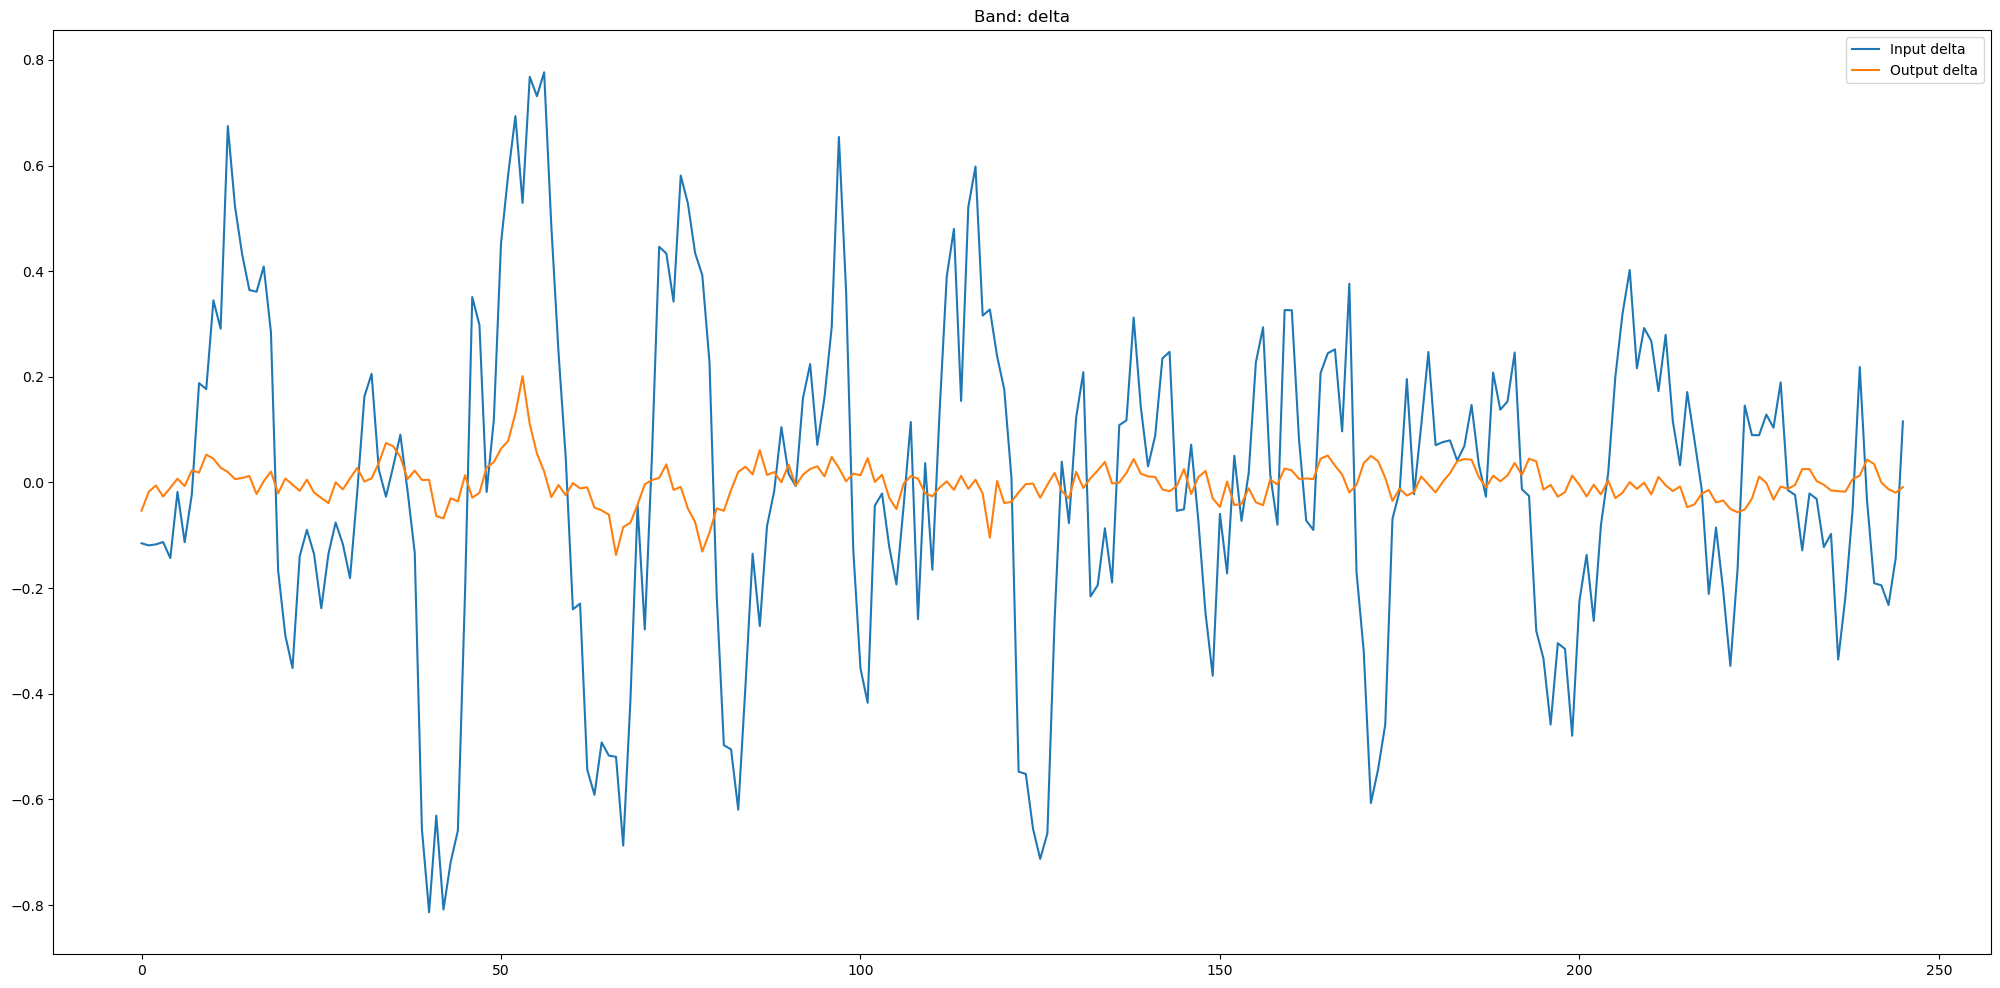

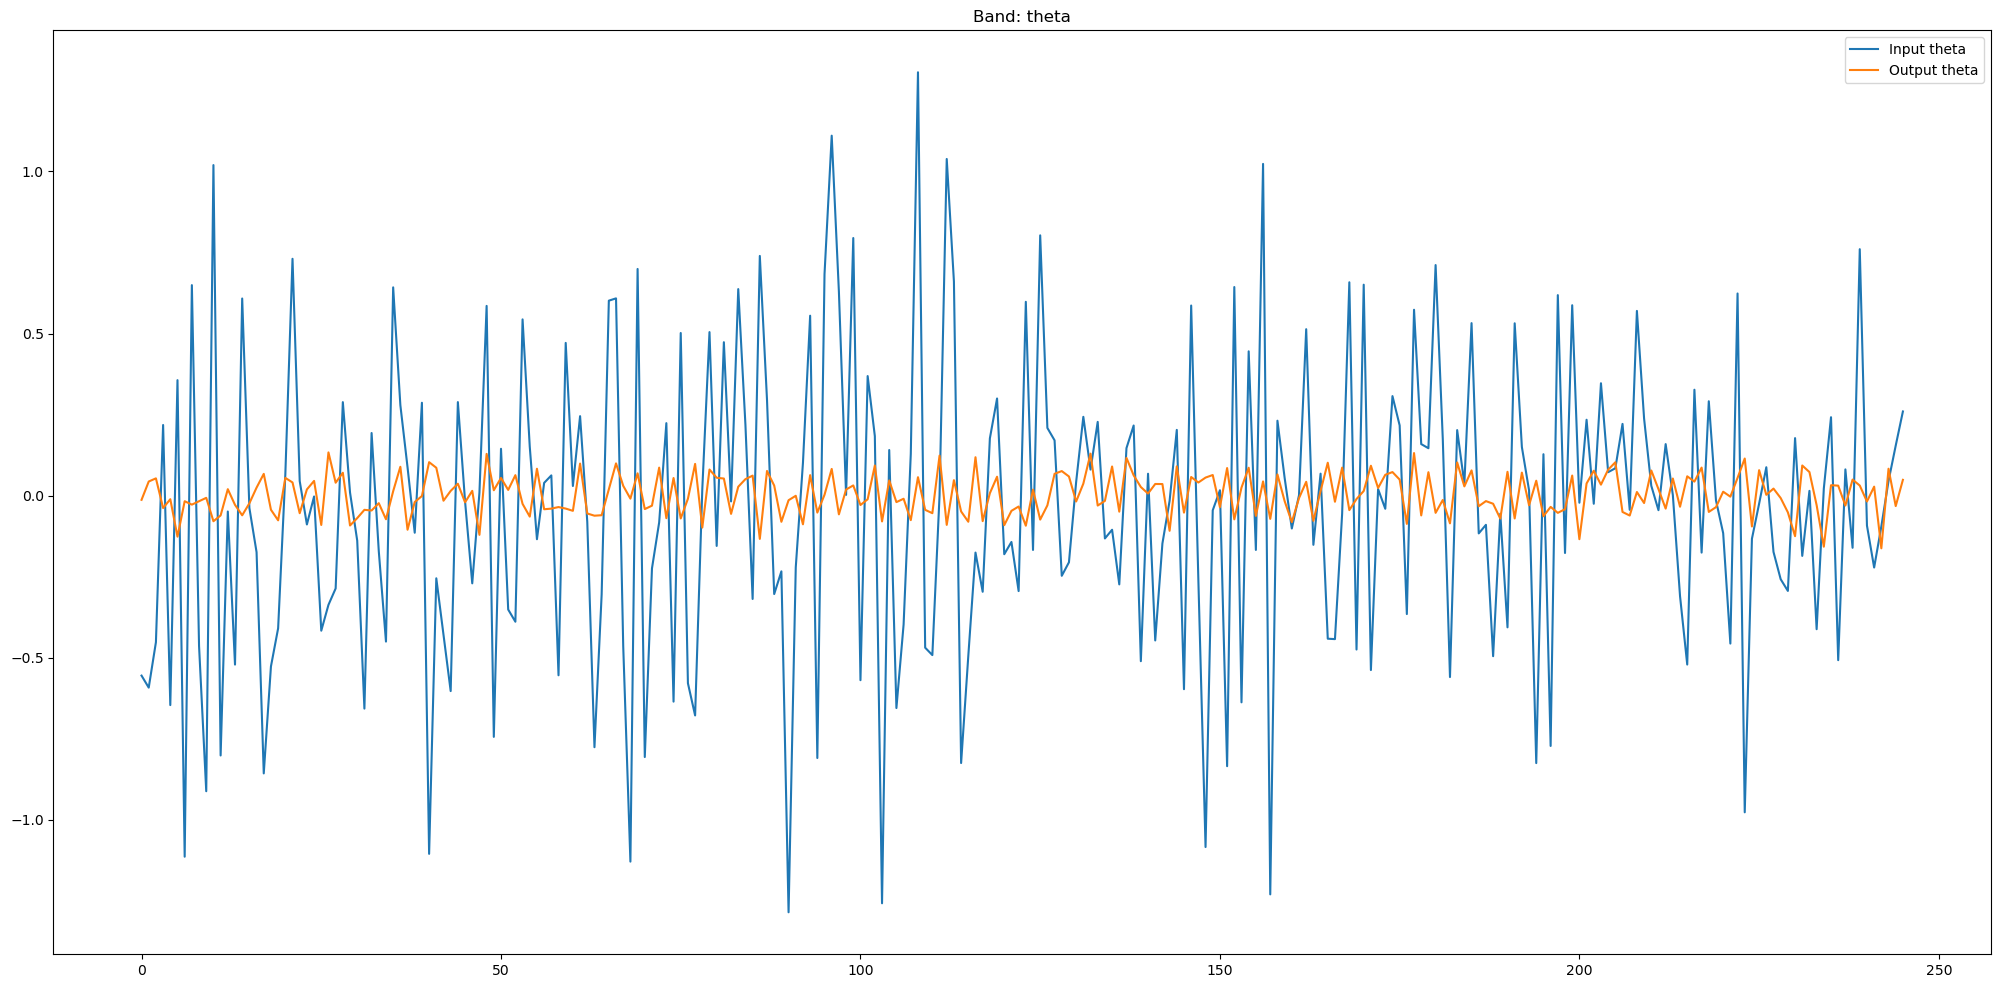

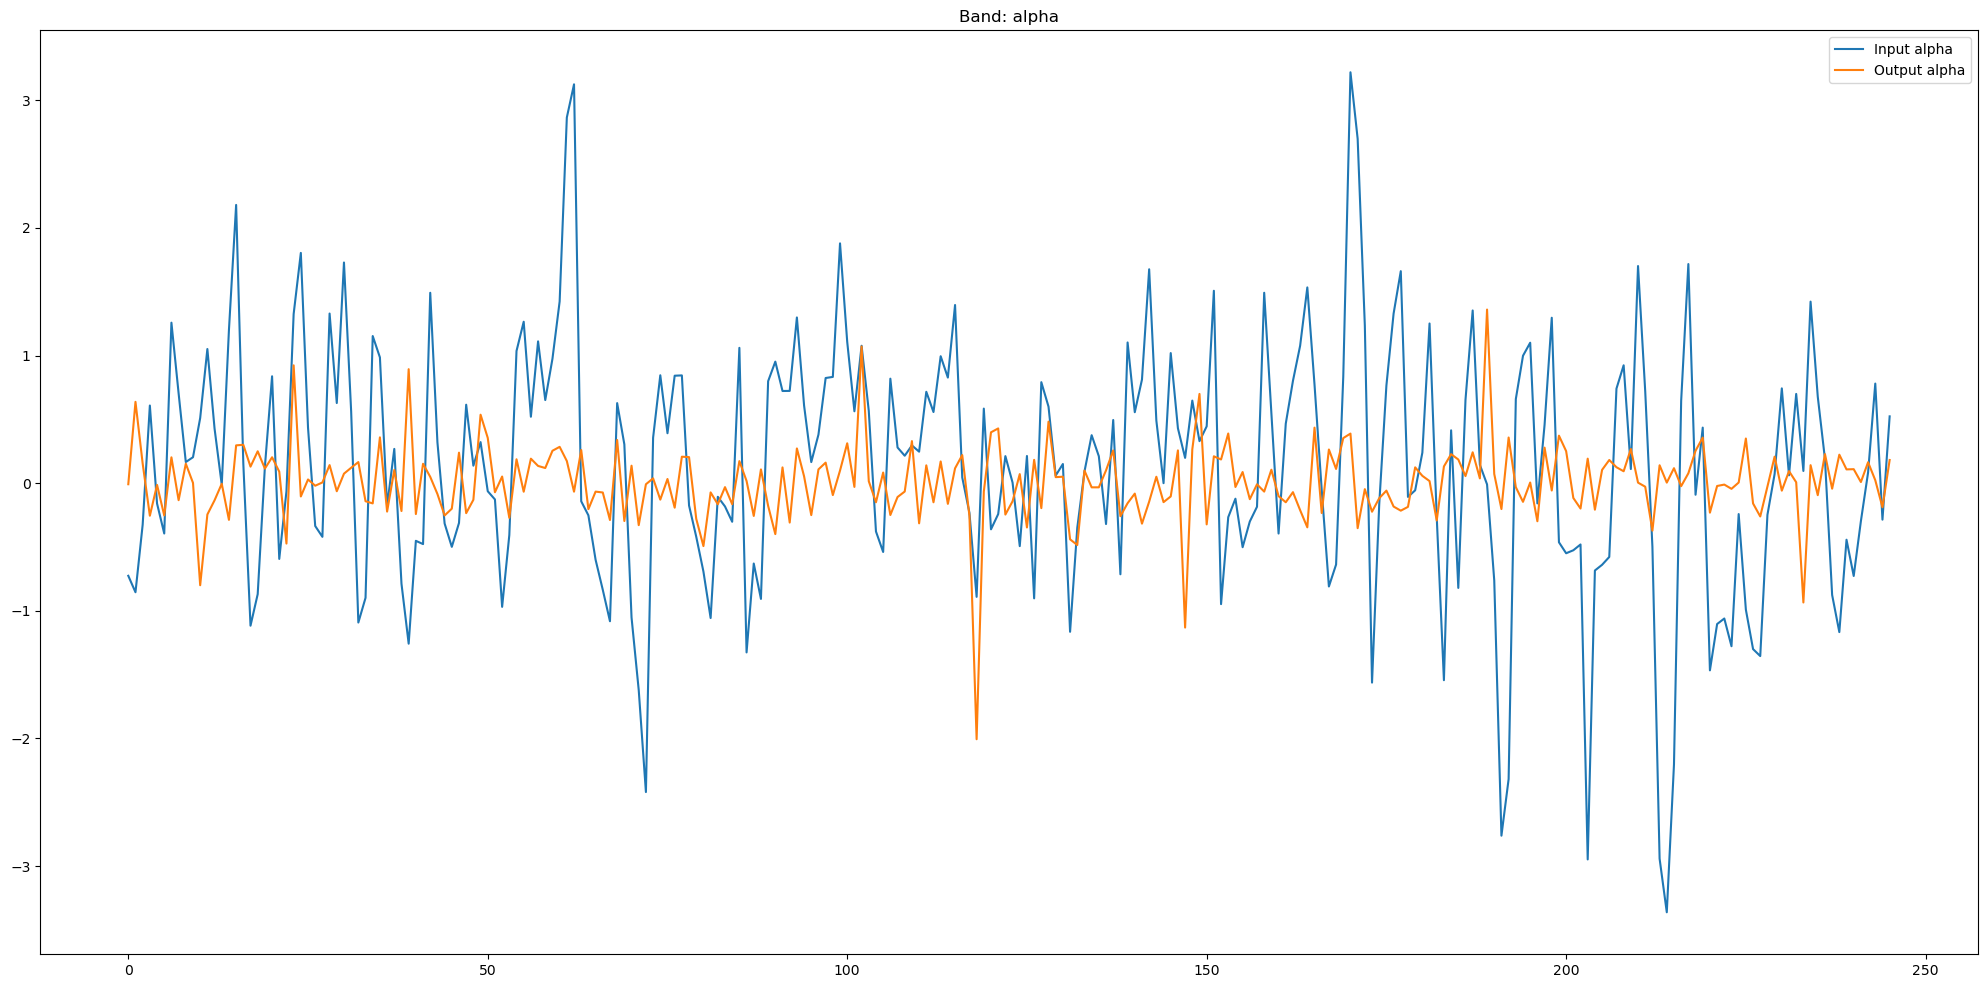

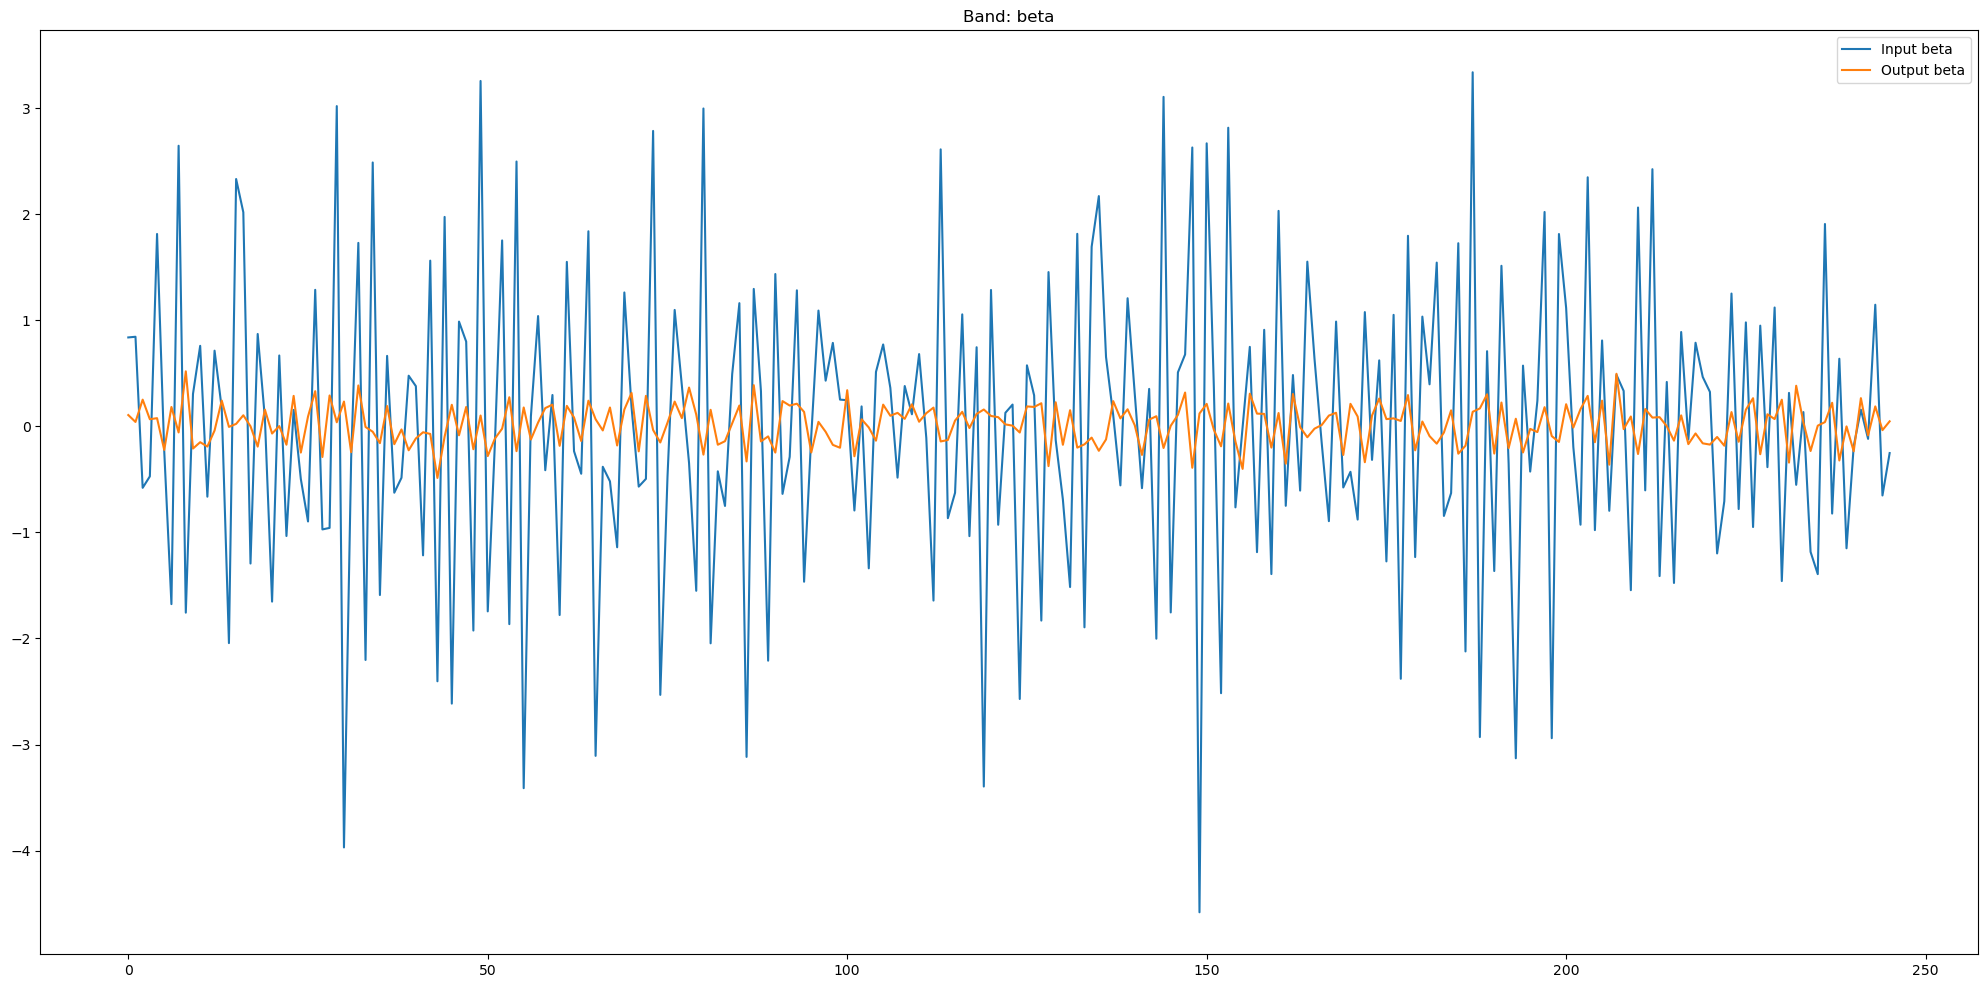

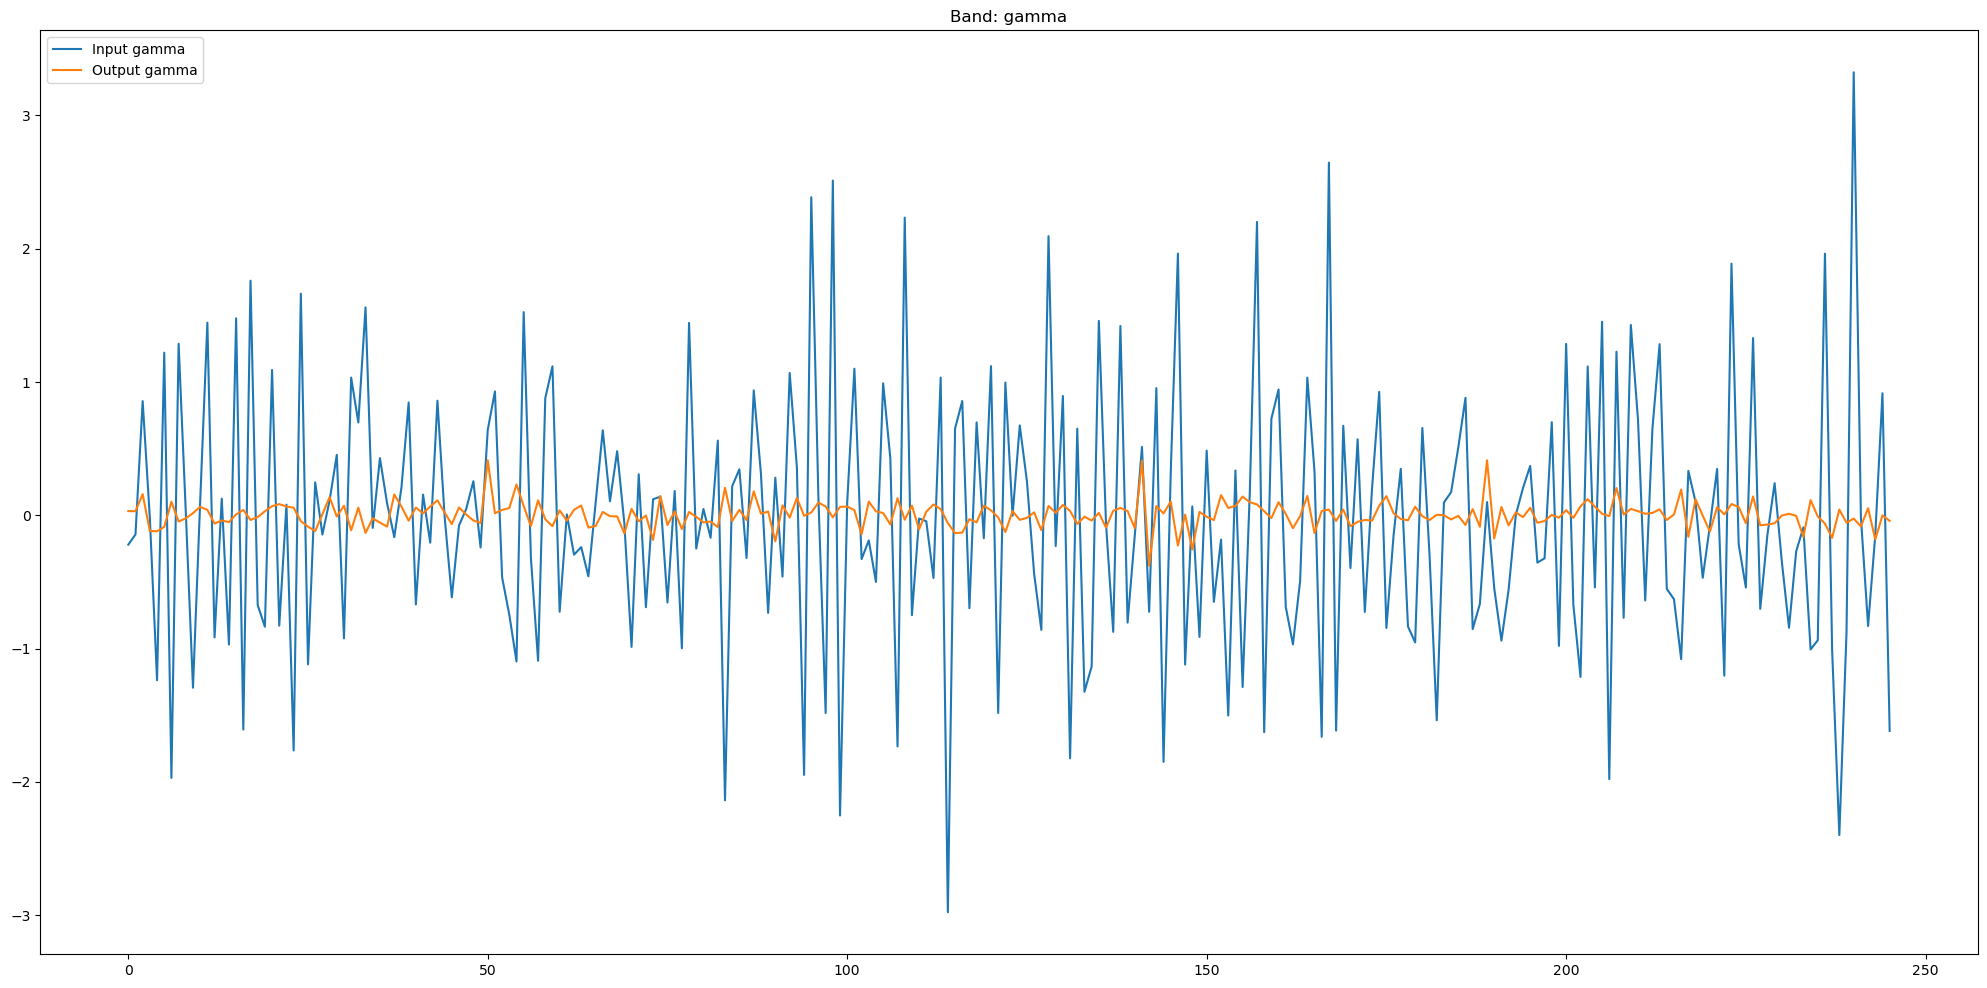

In [16]:
channel = 8
for band in ['delta', 'theta', 'alpha', 'beta', 'gamma']:
    plt.figure(figsize=(25, 12))
    plt.plot(inputs[band][0, channel, :246].cpu().detach().numpy(), label=f"Input {band}")
    plt.plot(outputs[band][1][0, channel, :246].cpu().detach().numpy(), label=f"Output {band}")
    plt.title(f"Band: {band}")
    plt.legend()
    plt.show()